# 07 - Ablation and Model Selection

## Goal
Run a focused ablation study (small runtime, still meaningful) and pick a final recommended config for reporting.

In [1]:
from pathlib import Path
import sys
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.project_utils import ensure_project_dirs, seed_everything

seed_everything(42)
paths = ensure_project_dirs()
abl_dir = paths["results"] / "ablations"
abl_dir.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = abl_dir / "ablation_results.csv"
SUMMARY_MD = abl_dir / "ablation_summary.md"
PLOT_MAE = abl_dir / "ablation_test_mae.png"
PLOT_TARGET_LAG = abl_dir / "ablation_target_lag.png"

sns.set_theme(style="whitegrid")
pd.options.display.max_columns = 200

print("Repo root:", ROOT)
print("Ablation dir:", abl_dir)

Repo root: C:\Users\User\Downloads\261-Project
Ablation dir: C:\Users\User\Downloads\261-Project\results\ablations


## Data inputs and protocol setup
- uses cached monthly data: `data/raw/fred_macro_monthly_raw.csv`
- rebuilds features/targets in-notebook for each ablation
- keeps the same split protocol across all runs
- primary project target remains `target_yoy_t_plus_1` (next-month YoY CPI); MoM target runs are sensitivity checks only


In [2]:
raw_path = paths["raw_data"] / "fred_macro_monthly_raw.csv"
if not raw_path.exists():
    raise FileNotFoundError("Missing raw monthly cache. Run notebook 01 first.")

raw_df = pd.read_csv(raw_path, index_col=0, parse_dates=True).sort_index()
raw_df.index = pd.to_datetime(raw_df.index)

split_meta_path = paths["processed_data"] / "split_metadata.json"
if split_meta_path.exists():
    split_meta = json.loads(split_meta_path.read_text(encoding="utf-8"))
else:
    split_meta = {
        "split_strategy": "covid_aware",
        "ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
        "covid_aware_windows": {"val_months": 24, "test_months": 24},
        "min_train_end_date": "2021-06-01",
    }

SPLIT_STRATEGY = split_meta.get("split_strategy", "covid_aware")
RATIOS = split_meta.get("ratios", {"train": 0.70, "val": 0.15, "test": 0.15})
COVID_WINDOWS = split_meta.get("covid_aware_windows", {"val_months": 24, "test_months": 24})
MIN_TRAIN_END_DATE = split_meta.get("min_train_end_date", "2021-06-01")

print("Raw shape:", raw_df.shape)
print("Date range:", raw_df.index.min().date(), "to", raw_df.index.max().date())
print("Split strategy:", SPLIT_STRATEGY)
print("Ratios:", RATIOS)
print("COVID windows:", COVID_WINDOWS)

Raw shape: (496, 11)
Date range: 1985-01-01 to 2026-04-01
Split strategy: covid_aware
Ratios: {'train': 0.7, 'val': 0.15, 'test': 0.15}
COVID windows: {'val_months': 24, 'test_months': 24}


In [3]:
def compute_split_bounds(index, strategy, ratios, covid_windows, min_train_end_date=None):
    n_rows = len(index)
    if strategy == "ratio":
        train_end = int(n_rows * ratios["train"])
        val_end = int(n_rows * (ratios["train"] + ratios["val"]))
    elif strategy == "covid_aware":
        val_months = int(covid_windows["val_months"])
        test_months = int(covid_windows["test_months"])
        val_end = n_rows - test_months
        train_end = val_end - val_months
        if min_train_end_date is not None and train_end > 0:
            min_dt = pd.Timestamp(min_train_end_date)
            if index[train_end - 1] < min_dt:
                shifted = int(index.searchsorted(min_dt, side="right"))
                train_end = min(max(shifted, 1), val_end - 1)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    if not (0 < train_end < val_end < n_rows):
        raise ValueError("Invalid split bounds")
    return train_end, val_end


def mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))


def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)))


def mase(y_true, y_pred, y_insample, m=1, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_insample = np.asarray(y_insample)
    scale = np.mean(np.abs(y_insample[m:] - y_insample[:-m]))
    return float(np.mean(np.abs(y_true - y_pred)) / (scale + eps))


def evaluate_metrics(y_true, y_pred, y_insample, mase_m=1):
    return {
        "mae": mae(y_true, y_pred),
        "smape": smape(y_true, y_pred),
        "mase": mase(y_true, y_pred, y_insample, m=mase_m),
    }


def make_flattened_names(base_features, n_lags):
    names = []
    for lag in range(n_lags, 0, -1):
        for f in base_features:
            names.append(f"{f}_lag{lag}")
    return names

In [4]:
def engineer_features(raw_df, target_mode="yoy", infl_smoothing="ema", ema_alpha=0.30):
    df = pd.DataFrame(index=raw_df.index)

    infl_mom = raw_df["CPI"].pct_change(1) * 100.0
    infl_yoy = raw_df["CPI"].pct_change(12) * 100.0
    infl_current = infl_yoy if target_mode == "yoy" else infl_mom

    df["Unemp_d"] = raw_df["Unemployment"].diff()
    df["Rate_d"] = raw_df["InterestRate"].diff()
    df["Oil_ret"] = np.log(raw_df["OilPrice"]).diff() * 100.0
    df["PPI_yoy"] = raw_df["PPI"].pct_change(12) * 100.0
    df["M2_yoy"] = raw_df["M2"].pct_change(12) * 100.0
    df["Retail_yoy"] = raw_df["RetailSales"].pct_change(12) * 100.0
    df["Employment_d"] = raw_df["Employment"].diff()
    df["Housing_d"] = raw_df["HousingStarts"].diff()
    df["T10Y"] = raw_df["Treasury10Y"]
    df["Sentiment"] = raw_df["Sentiment"]

    df["PPI_yoy_sq"] = df["PPI_yoy"] ** 2
    df["Oil_ret_sq"] = df["Oil_ret"] ** 2
    df["Rate_d_sq"] = df["Rate_d"] ** 2
    df["Unemp_d_sq"] = df["Unemp_d"] ** 2
    df["Rate_Unemp"] = df["Rate_d"] * df["Unemp_d"]
    df["Oil_PPI"] = df["Oil_ret"] * df["PPI_yoy"]

    if infl_smoothing in {"ema", "both"}:
        df["Infl_ema"] = infl_current.ewm(alpha=ema_alpha, adjust=False).mean()
    if infl_smoothing in {"ma", "both"}:
        df["Infl_ma3"] = infl_current.rolling(3).mean()
        df["Infl_ma6"] = infl_current.rolling(6).mean()

    df["Infl_vol6"] = infl_current.rolling(6).std()
    df["Inflation_prev"] = infl_current

    m = df.index.month
    df["MoY_sin"] = np.sin(2 * np.pi * m / 12.0)
    df["MoY_cos"] = np.cos(2 * np.pi * m / 12.0)

    covid_start = pd.Timestamp("2020-03-01")
    covid_end = pd.Timestamp("2021-06-30")
    df["COVID"] = ((df.index >= covid_start) & (df.index <= covid_end)).astype(int)

    target_col = f"target_{target_mode}_t_plus_1"
    df[target_col] = infl_current.shift(-1)

    return df, target_col


def select_features(df, feature_set="full", smoothing="ema"):
    full_features = [
        "Unemp_d", "Rate_d", "Oil_ret", "PPI_yoy", "M2_yoy", "Retail_yoy", "Employment_d",
        "Housing_d", "T10Y", "Sentiment", "PPI_yoy_sq", "Oil_ret_sq", "Rate_d_sq", "Unemp_d_sq",
        "Rate_Unemp", "Oil_PPI", "Infl_vol6", "Inflation_prev", "MoY_sin", "MoY_cos", "COVID"
    ]
    if smoothing == "ema":
        full_features += ["Infl_ema"]
    elif smoothing == "ma":
        full_features += ["Infl_ma3", "Infl_ma6"]
    else:
        full_features += ["Infl_ema", "Infl_ma3", "Infl_ma6"]

    small_features = [
        "Unemp_d", "Oil_ret", "PPI_yoy", "Employment_d", "Housing_d", "T10Y", "Sentiment",
        "Inflation_prev", "Infl_vol6", "MoY_sin", "MoY_cos", "COVID"
    ]
    if "Infl_ema" in full_features:
        small_features.append("Infl_ema")

    selected = full_features if feature_set == "full" else small_features
    selected = [f for f in selected if f in df.columns]
    return selected


def build_windows(X_df, y_sr, n_lags, representation):
    Xv = X_df.values.astype(np.float32)
    yv = y_sr.values.astype(np.float32)
    pv = X_df["Inflation_prev"].values.astype(np.float32)
    idx = X_df.index

    if representation == "mean_pooled":
        cols = list(X_df.columns)
    else:
        cols = make_flattened_names(list(X_df.columns), n_lags)

    XO, YO, PO, IO = [], [], [], []
    for i in range(n_lags, len(X_df)):
        block = Xv[i - n_lags : i, :]
        feat = block.mean(axis=0) if representation == "mean_pooled" else block.reshape(-1)
        XO.append(feat)
        YO.append(yv[i])
        PO.append(pv[i])
        IO.append(idx[i])

    Xw = pd.DataFrame(XO, columns=cols, index=pd.Index(IO, name="date"))
    yw = pd.Series(YO, index=Xw.index, name=y_sr.name)
    pw = pd.Series(PO, index=Xw.index, name="Inflation_prev")
    return Xw, yw, pw

## Focused ablation matrix
We keep this intentionally small (12 runs) so it stays practical but still covers key factors.

In [5]:
ABLATIONS = [
    {"run_id": "A0",  "target_mode": "yoy", "lag": 24, "feature_set": "full",  "representation": "mean_pooled"},
    {"run_id": "A1",  "target_mode": "mom", "lag": 24, "feature_set": "full",  "representation": "mean_pooled"},
    {"run_id": "A2",  "target_mode": "yoy", "lag": 36, "feature_set": "full",  "representation": "mean_pooled"},
    {"run_id": "A3",  "target_mode": "yoy", "lag": 60, "feature_set": "full",  "representation": "mean_pooled"},
    {"run_id": "A4",  "target_mode": "yoy", "lag": 24, "feature_set": "small", "representation": "mean_pooled"},
    {"run_id": "A5",  "target_mode": "yoy", "lag": 24, "feature_set": "full",  "representation": "flattened"},
    {"run_id": "A6",  "target_mode": "mom", "lag": 36, "feature_set": "full",  "representation": "mean_pooled"},
    {"run_id": "A7",  "target_mode": "mom", "lag": 60, "feature_set": "full",  "representation": "mean_pooled"},
    {"run_id": "A8",  "target_mode": "mom", "lag": 24, "feature_set": "small", "representation": "mean_pooled"},
    {"run_id": "A9",  "target_mode": "mom", "lag": 24, "feature_set": "full",  "representation": "flattened"},
    {"run_id": "A10", "target_mode": "yoy", "lag": 36, "feature_set": "full",  "representation": "flattened"},
    {"run_id": "A11", "target_mode": "mom", "lag": 36, "feature_set": "full",  "representation": "flattened"},
]

XGB_PARAMS = {
    "objective": "reg:squarederror",
    "n_estimators": 1400,
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 3,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 2.0,
    "reg_alpha": 0.1,
    "gamma": 0.0,
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": 1,
    "eval_metric": ["mae", "rmse"],
    "early_stopping_rounds": 60,
}

print("Number of ablation runs:", len(ABLATIONS))

Number of ablation runs: 12


In [6]:
rows = []

for cfg in ABLATIONS:
    feat_df, target_col = engineer_features(raw_df, target_mode=cfg["target_mode"], infl_smoothing="ema", ema_alpha=0.30)
    selected = select_features(feat_df, feature_set=cfg["feature_set"], smoothing="ema")

    model_df = feat_df[selected + [target_col]].dropna().copy()

    train_end, val_end = compute_split_bounds(
        index=model_df.index,
        strategy=SPLIT_STRATEGY,
        ratios=RATIOS,
        covid_windows=COVID_WINDOWS,
        min_train_end_date=MIN_TRAIN_END_DATE,
    )

    X_df_run = model_df[selected]
    y_sr_run = model_df[target_col]

    Xw, yw, pw = build_windows(X_df_run, y_sr_run, n_lags=cfg["lag"], representation=cfg["representation"])

    train_boundary_date = y_sr_run.index[train_end]
    val_boundary_date = y_sr_run.index[val_end]

    tr_mask = Xw.index < train_boundary_date
    va_mask = (Xw.index >= train_boundary_date) & (Xw.index < val_boundary_date)
    te_mask = Xw.index >= val_boundary_date

    X_train = Xw.loc[tr_mask]
    y_train = yw.loc[tr_mask]
    p_train = pw.loc[tr_mask]

    X_val = Xw.loc[va_mask]
    y_val = yw.loc[va_mask]
    p_val = pw.loc[va_mask]

    X_test = Xw.loc[te_mask]
    y_test = yw.loc[te_mask]
    p_test = pw.loc[te_mask]

    # same protocol checks
    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        continue
    assert X_train.index.max() < X_val.index.min() < X_test.index.min(), "Chronology violation"

    # delta-target for consistency with strongest current setup
    y_train_fit = (y_train.values - p_train.values)
    y_val_fit = (y_val.values - p_val.values)

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train_fit, eval_set=[(X_train, y_train_fit), (X_val, y_val_fit)], verbose=False)

    best_round = int(model.best_iteration) + 1 if model.best_iteration is not None else int(XGB_PARAMS["n_estimators"])

    val_pred = p_val.values + model.predict(X_val, iteration_range=(0, best_round))
    val_metrics = evaluate_metrics(y_val.values, val_pred, y_insample=y_train.values, mase_m=1)

    refit_params = dict(XGB_PARAMS)
    refit_params.pop("early_stopping_rounds", None)
    refit_params["n_estimators"] = best_round

    final_model = xgb.XGBRegressor(**refit_params)
    X_trainval = pd.concat([X_train, X_val], axis=0)
    y_trainval_fit = np.concatenate([
        y_train.values - p_train.values,
        y_val.values - p_val.values,
    ])
    final_model.fit(X_trainval, y_trainval_fit, verbose=False)

    test_pred = p_test.values + final_model.predict(X_test)
    test_metrics = evaluate_metrics(y_test.values, test_pred, y_insample=y_sr_run.iloc[:val_end].values, mase_m=1)

    rows.append({
        "run_id": cfg["run_id"],
        "target_mode": cfg["target_mode"],
        "lag": int(cfg["lag"]),
        "feature_set": cfg["feature_set"],
        "representation": cfg["representation"],
        "n_features": int(len(selected)),
        "n_train_windows": int(len(X_train)),
        "n_val_windows": int(len(X_val)),
        "n_test_windows": int(len(X_test)),
        "train_end": str(X_train.index.max().date()),
        "val_end": str(X_val.index.max().date()),
        "test_start": str(X_test.index.min().date()),
        "test_end": str(X_test.index.max().date()),
        "best_round": int(best_round),
        "val_mae": float(val_metrics["mae"]),
        "val_smape": float(val_metrics["smape"]),
        "val_mase": float(val_metrics["mase"]),
        "test_mae": float(test_metrics["mae"]),
        "test_smape": float(test_metrics["smape"]),
        "test_mase": float(test_metrics["mase"]),
        "protocol": f"{SPLIT_STRATEGY}|delta_target|xgb_refit_trainval",
    })

ablation_df = pd.DataFrame(rows).sort_values(["test_mae", "val_mae"]).reset_index(drop=True)
ablation_df.to_csv(RESULTS_CSV, index=False)

print("Saved:", RESULTS_CSV)
print("Runs completed:", len(ablation_df))
ablation_df.head(12)

C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_mom = raw_df["CPI"].pct_change(1) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_yoy = raw_df["CPI"].pct_change(12) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None'

C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_mom = raw_df["CPI"].pct_change(1) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_yoy = raw_df["CPI"].pct_change(12) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None'

C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_mom = raw_df["CPI"].pct_change(1) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_yoy = raw_df["CPI"].pct_change(12) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None'

C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_mom = raw_df["CPI"].pct_change(1) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_yoy = raw_df["CPI"].pct_change(12) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None'

C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_mom = raw_df["CPI"].pct_change(1) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_yoy = raw_df["CPI"].pct_change(12) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None'

C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_mom = raw_df["CPI"].pct_change(1) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_yoy = raw_df["CPI"].pct_change(12) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None'

C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_mom = raw_df["CPI"].pct_change(1) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  infl_yoy = raw_df["CPI"].pct_change(12) * 100.0
C:\Users\User\AppData\Local\Temp\ipykernel_24424\853088500.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None'

Saved: C:\Users\User\Downloads\261-Project\results\ablations\ablation_results.csv
Runs completed: 12


,run_id,target_mode,lag,feature_set,representation,n_features,n_train_windows,n_val_windows,n_test_windows,train_end,val_end,test_start,test_end,best_round,val_mae,val_smape,val_mase,test_mae,test_smape,test_mase,protocol
0,A9,mom,24,full,flattened,22,323,24,24,2021-11-01,2023-11-01,2023-12-01,2026-01-01,75,0.319002,87.353367,1.220859,0.145186,74.906331,0.560385,covid_aware|delta_target|xgb_refit_trainval
1,A8,mom,24,small,mean_pooled,13,406,24,24,2021-11-01,2023-11-01,2023-12-01,2026-01-01,31,0.327388,90.197271,1.337154,0.156509,80.164051,0.630756,covid_aware|delta_target|xgb_refit_trainval
2,A11,mom,36,full,flattened,22,311,24,24,2021-11-01,2023-11-01,2023-12-01,2026-01-01,114,0.313852,88.354564,1.186902,0.158870,85.736036,0.613203,covid_aware|delta_target|xgb_refit_trainval
3,A4,yoy,24,small,mean_pooled,13,402,24,24,2021-11-01,2023-11-01,2023-12-01,2026-01-01,21,0.416592,7.969371,1.530260,0.160286,5.739475,0.576113,covid_aware|delta_target|xgb_refit_trainval
4,A1,mom,24,full,mean_pooled,22,323,24,24,2021-11-01,2023-11-01,2023-12-01,2026-01-01,21,0.334792,90.142423,1.281288,0.162368,84.363651,0.626704,covid_aware|delta_target|xgb_refit_trainval
5,A5,yoy,24,full,flattened,22,323,24,24,2021-11-01,2023-11-01,2023-12-01,2026-01-01,29,0.383064,7.215434,1.310925,0.170038,6.003996,0.587603,covid_aware|delta_target|xgb_refit_trainval
6,A0,yoy,24,full,mean_pooled,22,323,24,24,2021-11-01,2023-11-01,2023-12-01,2026-01-01,36,0.361623,7.623946,1.237549,0.172166,6.120631,0.594956,covid_aware|delta_target|xgb_refit_trainval
7,A10,yoy,36,full,flattened,22,311,24,24,2021-11-01,2023-11-01,2023-12-01,2026-01-01,33,0.387743,7.460544,1.302248,0.172557,6.122445,0.596308,covid_aware|delta_target|xgb_refit_trainval
8,A2,yoy,36,full,mean_pooled,22,311,24,24,2021-11-01,2023-11-01,2023-12-01,2026-01-01,31,0.388067,7.984633,1.303335,0.178672,6.576869,0.617438,covid_aware|delta_target|xgb_refit_trainval
9,A6,mom,36,full,mean_pooled,22,311,24,24,2021-11-01,2023-11-01,2023-12-01,2026-01-01,104,0.317428,87.344217,1.200425,0.187726,90.929228,0.724580,covid_aware|delta_target|xgb_refit_trainval


## What each ablation teaches
- **Target mode (YoY vs MoM)**: smoother annual series vs more reactive monthly series
- **Lag length**: short-memory vs longer-memory windows
- **Feature set**: compact features vs full engineered set
- **Representation**: pooled summary vs full lag structure

In [7]:
if len(ablation_df) == 0:
    raise RuntimeError("No ablation run completed; check split/data settings.")

best_row = ablation_df.iloc[0].to_dict()

summary_lines = []
summary_lines.append("# Ablation Summary")
summary_lines.append("")
summary_lines.append("## Evaluation Protocol")
summary_lines.append(f"- split strategy: `{SPLIT_STRATEGY}`")
summary_lines.append("- training target for XGBoost: `delta = target_{t+1} - Inflation_prev_t`")
summary_lines.append("- model selection: lowest validation MAE")
summary_lines.append("- final scoring: held-out test after refit on train+val with selected boosting rounds")
summary_lines.append("")
summary_lines.append("## Recommended Configuration")
summary_lines.append(f"- run_id: `{best_row['run_id']}`")
summary_lines.append(f"- target_mode: `{best_row['target_mode']}`")
summary_lines.append(f"- lag: `{int(best_row['lag'])}`")
summary_lines.append(f"- feature_set: `{best_row['feature_set']}`")
summary_lines.append(f"- representation: `{best_row['representation']}`")
summary_lines.append(f"- test MAE: `{best_row['test_mae']:.4f}`")
summary_lines.append(f"- test sMAPE: `{best_row['test_smape']:.4f}`")
summary_lines.append(f"- test MASE: `{best_row['test_mase']:.4f}`")
summary_lines.append("")
summary_lines.append("## Notes")
summary_lines.append("- Use this recommended configuration as the default candidate in the report notebook.")
summary_lines.append("- Keep naive and ARIMA baselines in final comparison to show practical gains.")

SUMMARY_MD.write_text("\n".join(summary_lines), encoding="utf-8")
print("Saved:", SUMMARY_MD)
print("Best row:", pd.Series(best_row), sep="\n")


Saved: C:\Users\User\Downloads\261-Project\results\ablations\ablation_summary.md
Best row:
run_id                                                      A9
target_mode                                                mom
lag                                                         24
feature_set                                               full
representation                                       flattened
n_features                                                  22
n_train_windows                                            323
n_val_windows                                               24
n_test_windows                                              24
train_end                                           2021-11-01
val_end                                             2023-11-01
test_start                                          2023-12-01
test_end                                            2026-01-01
best_round                                                  75
val_mae                    

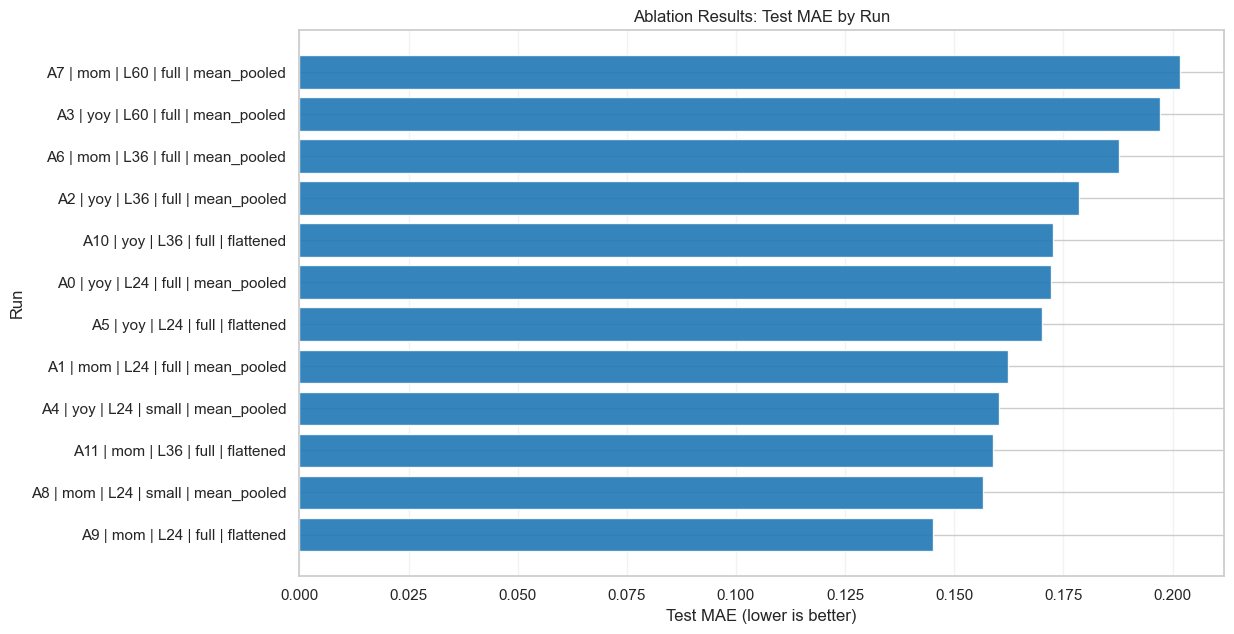

Saved: C:\Users\User\Downloads\261-Project\results\ablations\ablation_test_mae.png


In [8]:
# Plot 1: test MAE per run
plot_df = ablation_df.copy()
plot_df["label"] = plot_df["run_id"] + " | " + plot_df["target_mode"] + " | L" + plot_df["lag"].astype(str) + " | " + plot_df["feature_set"] + " | " + plot_df["representation"]

fig, ax = plt.subplots(figsize=(12.5, 6.5))
plot_df_sorted = plot_df.sort_values("test_mae", ascending=True)
ax.barh(plot_df_sorted["label"], plot_df_sorted["test_mae"], color="#1f77b4", alpha=0.9)
ax.set_title("Ablation Results: Test MAE by Run")
ax.set_xlabel("Test MAE (lower is better)")
ax.set_ylabel("Run")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(PLOT_MAE, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", PLOT_MAE)

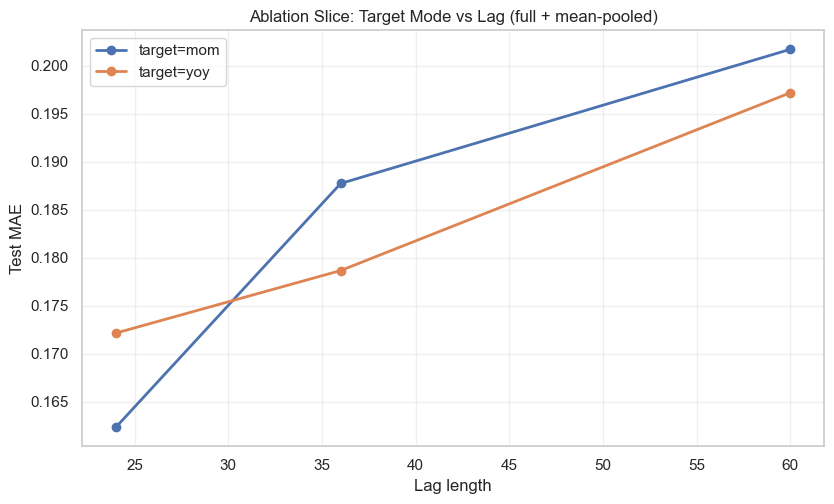

Saved: C:\Users\User\Downloads\261-Project\results\ablations\ablation_target_lag.png


In [9]:
# Plot 2: target-mode vs lag comparison on full+mean-pooled subset
subset = ablation_df[(ablation_df["feature_set"] == "full") & (ablation_df["representation"] == "mean_pooled")]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
for tm, g in subset.groupby("target_mode"):
    g = g.sort_values("lag")
    ax.plot(g["lag"], g["test_mae"], marker="o", linewidth=2, label=f"target={tm}")

ax.set_title("Ablation Slice: Target Mode vs Lag (full + mean-pooled)")
ax.set_xlabel("Lag length")
ax.set_ylabel("Test MAE")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_TARGET_LAG, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", PLOT_TARGET_LAG)

## Verification
- all runs share one protocol signature
- all runs are chronological
- final recommended config is explicitly flagged

In [10]:
# Protocol consistency check
protocols = set(ablation_df["protocol"].unique())
assert len(protocols) == 1, f"Multiple protocols detected: {protocols}"

# Chronology check for each run
for _, r in ablation_df.iterrows():
    assert pd.Timestamp(r["train_end"]) < pd.Timestamp(r["test_start"]), f"Chronology failed in {r['run_id']}"

# Recommended config marker
recommended = ablation_df.iloc[0]
print("Protocol consistency: PASS")
print("Chronology checks: PASS")
print("Recommended configuration for report:")
print(recommended[["run_id", "target_mode", "lag", "feature_set", "representation", "test_mae", "test_smape", "test_mase"]])

Protocol consistency: PASS
Chronology checks: PASS
Recommended configuration for report:
run_id                   A9
target_mode             mom
lag                      24
feature_set            full
representation    flattened
test_mae           0.145186
test_smape        74.906331
test_mase          0.560385
Name: 0, dtype: object
